## Quadratures approximations of integrals

In [ ]:
# approximate ln 2 with 3 correct decimals, bu applying the repeated rectangle, trapezoid and Simpson's rule to the integral of 1/x dx from 1 to 2 with the appropriate number of subintervals. Compute the errors of the approximations.

In [10]:
import math


def f(x):
    return 1 / x


def composite_midpoint(a, b, n):
    h = (b - a) / n
    return h * sum(f(a + (i + 0.5) * h) for i in range(n))


def composite_trapezoid(a, b, n):
    h = (b - a) / n
    interior_sum = sum(f(a + i * h) for i in range(1, n))
    return h * ((f(a) + f(b)) / 2 + interior_sum)


def composite_simpson(a, b, n):
    if n % 2 != 0:
        raise ValueError("Simpson's rule requires an even number of subintervals.")
    h = (b - a) / n
    odd_sum = sum(f(a + i * h) for i in range(1, n, 2))
    even_sum = sum(f(a + i * h) for i in range(2, n, 2))
    return h / 3 * (f(a) + f(b) + 4 * odd_sum + 2 * even_sum)


def find_min_n_by_error(method, exact_value, error_threshold=1e-4, n_start=1, even_required=False):
    n = n_start
    while True:
        if even_required and n % 2 != 0:
            n += 1
        approx = method(1, 2, n)
        error = abs(exact_value - approx)
        if error <= error_threshold:
            return n, approx, error
        n += 1


exact_value = math.log(2)

n_mid, approx_mid, err_mid = find_min_n_by_error(composite_midpoint, exact_value)
n_trap, approx_trap, err_trap = find_min_n_by_error(composite_trapezoid, exact_value)
n_simp, approx_simp, err_simp = find_min_n_by_error(
    composite_simpson, exact_value, n_start=2, even_required=True
)

print(f"Exact value ln(2) = {exact_value:.12f}\n")
print("Method                 n      Approximation      Absolute error")
print("-" * 64)
print(f"Composite rectangle    {n_mid:<6} {approx_mid:<18.12f} {err_mid:.12e}")
print(f"Composite trapezoid    {n_trap:<6} {approx_trap:<18.12f} {err_trap:.12e}")
print(f"Composite Simpson      {n_simp:<6} {approx_simp:<18.12f} {err_simp:.12e}")

Exact value ln(2) = 0.693147180560

Method                 n      Approximation      Absolute error
----------------------------------------------------------------
Composite rectangle    18     0.693050794951     9.638560912073e-05
Composite trapezoid    25     0.693247160576     9.998001597278e-05
Composite Simpson      6      0.693169793170     2.261260984793e-05


In [ ]:
'''
plot the graph of the function f(x) = x*e^(-x)/(x^2 + 1) for x in [0,1]

approximate the area under f, using all three composite rules mentioned above, for n = 2, 4, 8, ..., 256. Compute the errors.
'''

'\nplot the graph of the funciton f(x) =  x*e^(-x)/(x^2 - 1) for x in [0,1]\n\napproximate the area under f, using all three composite rules mentioned above, for n = 10\n'

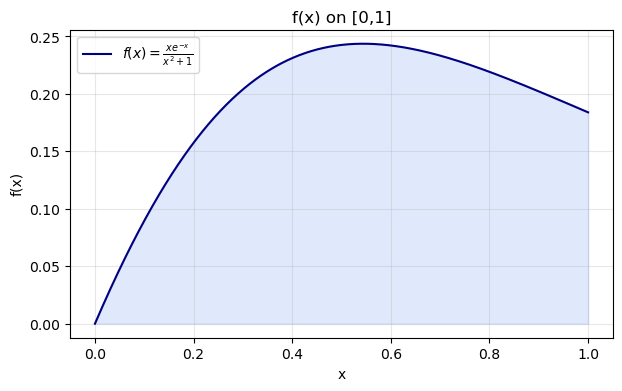

Integral value from mpmath (80 dps): 0.19232940611584510981330271547209651271190712532607233001652012456176717429359633
Integral value used for errors: 0.192329406115845

   n |       Midpoint |     Err(mid) |      Trapezoid |    Err(trap) |        Simpson |    Err(simp)
----------------------------------------------------------------------------------------------------
   2 |   0.2049915942 |   1.2662e-02 |   0.1672910621 |   2.5038e-02 |   0.1923981294 |   6.8723e-05
   4 |   0.1954316361 |   3.1022e-03 |   0.1861413281 |   6.1881e-03 |   0.1924247502 |   9.5344e-05
   8 |   0.1931013697 |   7.7196e-04 |   0.1907864821 |   1.5429e-03 |   0.1923348668 |   5.4606e-06
  16 |   0.1925221774 |   1.9277e-04 |   0.1919439259 |   3.8548e-04 |   0.1923297405 |   3.3438e-07
  32 |   0.1923775853 |   4.8179e-05 |   0.1922330517 |   9.6354e-05 |   0.1923294269 |   2.0800e-08
  64 |   0.1923414501 |   1.2044e-05 |   0.1923053185 |   2.4088e-05 |   0.1923294074 |   1.2985e-09
 128 |   0.1923324170

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import math
import mpmath as mp


def f(x):
    return x * math.exp(-x) / (x**2 + 1)


def f_vec(x):
    return x * np.exp(-x) / (x**2 + 1)


a, b = 0.0, 1.0
n_values = [2**k for k in range(1, 9)]

x = np.linspace(a, b, 1000)
y = f_vec(x)

plt.figure(figsize=(7, 4))
plt.plot(x, y, label=r"$f(x)=\frac{x e^{-x}}{x^2+1}$", color="navy")
plt.fill_between(x, y, 0, alpha=0.2, color="cornflowerblue")
plt.title("f(x) on [0,1]")
plt.xlabel("x")
plt.ylabel("f(x)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

mp.mp.dps = 80
f_mp = lambda x: x * mp.e**(-x) / (x**2 + 1)
exact_ref_mp = mp.quad(f_mp, [a, b])
exact_ref = float(exact_ref_mp)

print(f"Integral value from mpmath (80 dps): {exact_ref_mp}")
print(f"Integral value used for errors: {exact_ref:.15f}\n")

header = (
    f"{'n':>4} | {'Midpoint':>14} | {'Err(mid)':>12} | "
    f"{'Trapezoid':>14} | {'Err(trap)':>12} | "
    f"{'Simpson':>14} | {'Err(simp)':>12}"
)
print(header)
print("-" * len(header))

for n in n_values:
    mid = composite_midpoint(a, b, n)
    trap = composite_trapezoid(a, b, n)
    simp = composite_simpson(a, b, n)

    err_mid = abs(exact_ref - mid)
    err_trap = abs(exact_ref - trap)
    err_simp = abs(exact_ref - simp)

    print(
        f"{n:4d} | {mid:14.10f} | {err_mid:12.4e} | "
        f"{trap:14.10f} | {err_trap:12.4e} | "
        f"{simp:14.10f} | {err_simp:12.4e}"
    )

In [ ]:
'''
the error function is defined as:
erf(x) = 2/sqrt(pi) * integral from 0 to x of e^(-t^2) dt
use the composite trapezoid rule to approximate the integral of erf(x) from 0 to 1, for n = 10. compute the error of the approximation.
'''

In [13]:
import math


f = math.erf

a, b = 0.0, 1.0
n = 10

trap_approx = composite_trapezoid(a, b, n)

exact_value = math.erf(1.0) + (math.exp(-1.0) - 1.0) / math.sqrt(math.pi)
abs_error = abs(exact_value - trap_approx)

print(f"Approximation (composite trapezoid, n=10): {trap_approx:.12f}")
print(f"Exact value: {exact_value:.12f}")
print(f"Absolute error: {abs_error:.12e}")

Approximation (composite trapezoid, n=10): 0.485470135584
Exact value: 0.486064958112
Absolute error: 5.948225284257e-04
